# Lab 02 — Language Models



## 13. Experiment 1 — Corpus statistics

### 13.1. Thiết lập và tải dữ liệu




In [1]:
from collections import Counter
from math import exp, isfinite
from pathlib import Path
import gc
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'labs').exists():
    REPO_ROOT = REPO_ROOT.parents[1]
sys.path.insert(0, str(REPO_ROOT))

from labs.lab02.ngram_lm import (
    BOS, EOS, UNK, NGramLanguageModel, build_vocabulary, count_ngrams,
    iter_ngrams,
    load_c4_documents, prepare_sentences, probability,
    sentence_log_probability, sentence_probability, tokenize,
    train_bigram, train_trigram, train_unigram,
)

LAB_DIR = REPO_ROOT / 'labs/lab02'
DATA_PATH = LAB_DIR / 'data/c4-train.00000-of-01024-30K.json.gz'
RESULTS_PATH = LAB_DIR / 'results.csv'
DOCUMENT_LIMIT = 10_000
RANDOM_SEED = 42

assert DATA_PATH.exists(), f'Missing dataset: {DATA_PATH}'
documents = load_c4_documents(DATA_PATH, limit=DOCUMENT_LIMIT)
print(f'Loaded {len(documents):,} documents from {DATA_PATH.name}')


Loaded 10,000 documents from c4-train.00000-of-01024-30K.json.gz


### 13.2. Sentence splitting, tokenization và train/validation/test split

Dữ liệu được chuẩn hóa, tokenize và chia train/validation/test theo document với tỉ lệ 80/10/10.

In [2]:
rng = np.random.default_rng(RANDOM_SEED)
indices = rng.permutation(len(documents))
train_end = int(0.8 * len(indices))
valid_end = int(0.9 * len(indices))

train_documents = [documents[index] for index in indices[:train_end]]
validation_documents = [documents[index] for index in indices[train_end:valid_end]]
test_documents = [documents[index] for index in indices[valid_end:]]

train_sentences = prepare_sentences(train_documents, max_sentence_length=80)
validation_sentences = prepare_sentences(validation_documents, max_sentence_length=80)
test_sentences = prepare_sentences(test_documents, max_sentence_length=80)
sentences = train_sentences + validation_sentences + test_sentences

split_summary = pd.DataFrame([
    {'split': 'train', 'sentences': len(train_sentences), 'tokens': sum(map(len, train_sentences))},
    {'split': 'validation', 'sentences': len(validation_sentences), 'tokens': sum(map(len, validation_sentences))},
    {'split': 'test', 'sentences': len(test_sentences), 'tokens': sum(map(len, test_sentences))},
])
split_summary


,split,sentences,tokens
0,train,179632,2907839
1,validation,23055,378950
2,test,22726,373325


### 13.3. Thống kê corpus

Thống kê trên 10.000 documents; vocabulary của model chỉ được tạo từ training split.

In [3]:
raw_token_counts = Counter(token for sentence in sentences for token in sentence)
corpus_summary = pd.DataFrame([{
    'documents': len(documents),
    'sentences': len(sentences),
    'tokens': sum(raw_token_counts.values()),
    'vocabulary_size': len(raw_token_counts),
}])
corpus_summary


,documents,sentences,tokens,vocabulary_size
0,10000,225413,3660114,99739


### 13.4. Số unique n-gram và singleton




In [4]:
ngram_stat_rows = []
frequency_profiles = {}
for n in (1, 2, 3):
    counts = count_ngrams(sentences, n)
    ngram_stat_rows.append({
        'model': f'{n}-gram',
        'unique_ngrams': len(counts),
        'singleton_ngrams': sum(value == 1 for value in counts.values()),
        'singleton_rate': sum(value == 1 for value in counts.values()) / len(counts),
    })
    frequency_profiles[n] = Counter(counts.values())
    del counts
    gc.collect()

ngram_statistics = pd.DataFrame(ngram_stat_rows)
ngram_statistics


,model,unique_ngrams,singleton_ngrams,singleton_rate
0,1-gram,99740,45651,0.457700
1,2-gram,1222232,886166,0.725039
2,3-gram,2624604,2291596,0.873121


### 13.5. Frequency distribution

Phân phối tần suất n-gram trên thang log.

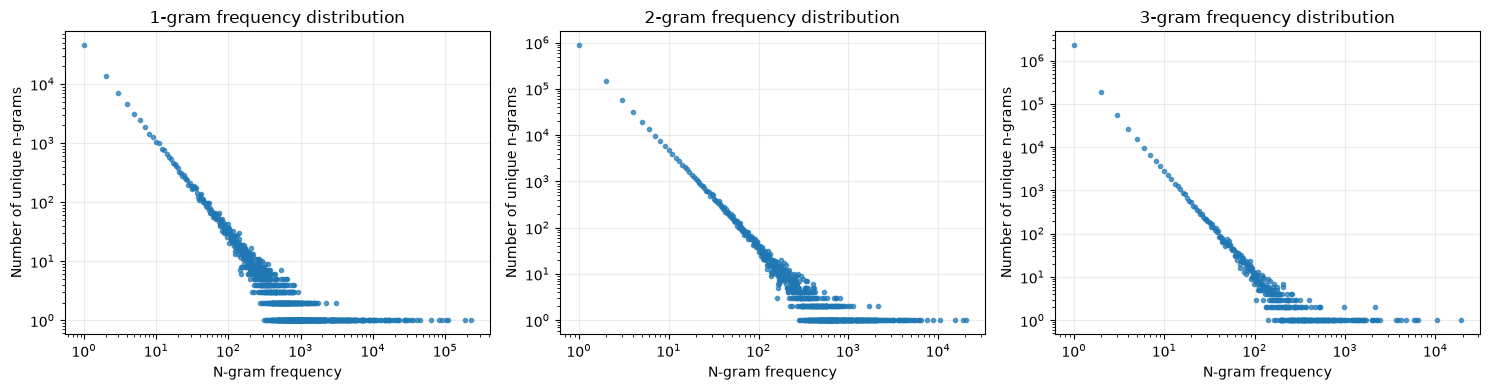

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for n, axis in zip((1, 2, 3), axes):
    profile = frequency_profiles[n]
    frequencies = sorted(profile)
    type_counts = [profile[value] for value in frequencies]
    axis.loglog(frequencies, type_counts, marker='.', linestyle='none', alpha=0.7)
    axis.set_title(f'{n}-gram frequency distribution')
    axis.set_xlabel('N-gram frequency')
    axis.set_ylabel('Number of unique n-grams')
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 14. Core implementation

### 14.1. API tự cài đặt

Các hàm cốt lõi được tự cài đặt trong `ngram_lm.py`.

In [6]:
required_functions = {
    'build_vocabulary': build_vocabulary,
    'count_ngrams': count_ngrams,
    'train_unigram': train_unigram,
    'train_bigram': train_bigram,
    'train_trigram': train_trigram,
    'probability': probability,
    'sentence_probability': sentence_probability,
    'sentence_log_probability': sentence_log_probability,
}
pd.DataFrame({
    'function': list(required_functions),
    'callable': [callable(function) for function in required_functions.values()],
})


,function,callable
0,build_vocabulary,True
1,count_ngrams,True
2,train_unigram,True
3,train_bigram,True
4,train_trigram,True
5,probability,True
6,sentence_probability,True
7,sentence_log_probability,True


### 14.2. Unit tests trên toy corpus

Kiểm tra count, probability, smoothing, log probability và perplexity trên toy corpus.

In [7]:
toy_corpus = [
    tokenize('the cat eats fish'),
    tokenize('the cat likes fish'),
    tokenize('the dog eats meat'),
]
toy_unigram = train_unigram(toy_corpus, min_count=1)
toy_bigram = train_bigram(toy_corpus, min_count=1)
toy_trigram = train_trigram(toy_corpus, min_count=1)

assert count_ngrams(toy_corpus, 1)[('the',)] == 3
assert count_ngrams(toy_corpus, 2)[('the', 'cat')] == 2
assert count_ngrams(toy_corpus, 3)[('the', 'cat', 'eats')] == 1
assert np.isclose(toy_bigram.probability(['the'], 'cat'), 2/3)
assert np.isclose(toy_bigram.probability(['cat'], 'eats'), 1/2)
expected_laplace = (1 + 1) / (2 + toy_bigram.vocabulary_size)
assert np.isclose(toy_bigram.probability(['cat'], 'eats', 'laplace'), expected_laplace)
assert np.isfinite(toy_trigram.sentence_log_probability('the cat eats fish'))
assert np.isfinite(toy_trigram.perplexity(toy_corpus, 'mle'))
print('All core implementation checks passed.')


All core implementation checks passed.


## 15. Log probability

Khi nhân nhiều xác suất nhỏ hơn 1, kết quả có thể quá nhỏ và bị làm tròn thành 0 (numerical underflow). Log probability biến phép nhân thành phép cộng:

$$\log P(S)=\sum_t \log P(w_t\mid context)$$

Vì vậy, giá trị vẫn có thể được biểu diễn ổn định với câu dài.

In [8]:
long_sentence = ['the'] * 5_000
long_log_probability = toy_unigram.sentence_log_probability(
    long_sentence, smoothing='laplace'
)
direct_probability = exp(long_log_probability)
pd.DataFrame([{
    'tokens': len(long_sentence),
    'log_probability': long_log_probability,
    'exp_log_probability': direct_probability,
    'underflow_detected': direct_probability == 0.0,
}])


,tokens,log_probability,exp_log_probability,underflow_detected
0,5000,-8960.589106,0.0,True


## 16. Experiment 2 — MLE vs Laplace smoothing

### 16.1. Huấn luyện unigram, bigram và trigram

Train unigram, bigram và trigram với `min_count=2`; đánh giá bằng MLE và Laplace.

In [9]:
split_data = {
    'train': train_sentences,
    'validation': validation_sentences,
    'test': test_sentences,
}
model_rows = []
perplexity_rows = []
unseen_rows = []
trigram_model = None

for n in (1, 2, 3):
    model = NGramLanguageModel(n=n, min_count=2).fit(train_sentences)
    model_rows.append({
        'model': f'{n}-gram',
        'vocabulary_size': model.vocabulary_size,
        'unique_ngrams': model.unique_ngrams,
        'singleton_ngrams': model.singleton_ngrams,
    })
    for split_name in ('validation', 'test'):
        total_events = 0
        unseen_events = 0
        unseen_types = set()
        for sentence in split_data[split_name]:
            for ngram in iter_ngrams(sentence, n, model.vocabulary):
                total_events += 1
                if model.ngram_counts[ngram] == 0:
                    unseen_events += 1
                    unseen_types.add(ngram)
        unseen_rows.append({
            'result_type': 'unseen_ngram',
            'model': f'{n}-gram',
            'split': split_name,
            'total_ngram_events': total_events,
            'unseen_ngram_events': unseen_events,
            'unique_unseen_ngrams': len(unseen_types),
            'unseen_event_rate': unseen_events / total_events,
        })
    for smoothing in ('mle', 'laplace'):
        for split_name, split_corpus in split_data.items():
            perplexity_rows.append({
                'result_type': 'perplexity',
                'model': f'{n}-gram',
                'smoothing': smoothing,
                'split': split_name,
                'perplexity': model.perplexity(split_corpus, smoothing=smoothing),
            })
    if n == 3:
        trigram_model = model
    else:
        del model
        gc.collect()

model_statistics = pd.DataFrame(model_rows)
perplexity_results = pd.DataFrame(perplexity_rows)
unseen_results = pd.DataFrame(unseen_rows)
display(model_statistics)
display(perplexity_results.pivot_table(
    index=['model', 'smoothing'], columns='split', values='perplexity', aggfunc='first'
))
unseen_results


,model,vocabulary_size,unique_ngrams,singleton_ngrams
0,1-gram,47828,47828,0
1,2-gram,47828,963044,680231
2,3-gram,47828,2101787,1833110


split                     test         train    validation
model  smoothing                                          
1-gram laplace    1.225379e+03   1376.974144  1.235599e+03
       mle        1.221261e+03   1375.106708  1.231328e+03
2-gram laplace    3.588691e+03   2955.890699  3.671153e+03
       mle                 inf    124.655474           inf
3-gram laplace    1.885426e+04  11394.421356  1.922881e+04
       mle                 inf     10.279168           inf

,result_type,model,split,total_ngram_events,unseen_ngram_events,unique_unseen_ngrams,unseen_event_rate
0,unseen_ngram,1-gram,validation,402005,0,0,0.000000
1,unseen_ngram,1-gram,test,396051,0,0,0.000000
2,unseen_ngram,2-gram,validation,402005,97117,85942,0.241582
3,unseen_ngram,2-gram,test,396051,94680,81968,0.239060
4,unseen_ngram,3-gram,validation,402005,256522,241776,0.638106
5,unseen_ngram,3-gram,test,396051,249642,231906,0.630328


### 16.2. Zero probability và tác động của smoothing

MLE có thể cho zero probability; Laplace giúp mọi n-gram có xác suất dương.

In [10]:
finite_check = perplexity_results.assign(
    finite=perplexity_results['perplexity'].map(np.isfinite)
)
finite_check[['model', 'smoothing', 'split', 'perplexity', 'finite']]


,model,smoothing,split,perplexity,finite
0,1-gram,mle,train,1.375107e+03,True
1,1-gram,mle,validation,1.231328e+03,True
2,1-gram,mle,test,1.221261e+03,True
3,1-gram,laplace,train,1.376974e+03,True
4,1-gram,laplace,validation,1.235599e+03,True
5,1-gram,laplace,test,1.225379e+03,True
6,2-gram,mle,train,1.246555e+02,True
7,2-gram,mle,validation,inf,False
8,2-gram,mle,test,inf,False
9,2-gram,laplace,train,2.955891e+03,True


## 17. Perplexity

Perplexity thấp hơn cho thấy model dự đoán tốt hơn trên cùng dữ liệu.

## 18. Bài tập tính Perplexity

Phần tính tay nằm trong `calculations.md`.

## 19. Experiment 3 — Perplexity

### 19.1. So sánh theo context length

So sánh perplexity trên cùng train/validation/test split.

In [11]:
laplace_ppl = perplexity_results[
    perplexity_results['smoothing'] == 'laplace'
].pivot(index='model', columns='split', values='perplexity')
laplace_ppl = laplace_ppl[['train', 'validation', 'test']]
laplace_ppl


split,train,validation,test
model,,,
1-gram,1376.974144,1235.599068,1225.379162
2-gram,2955.890699,3671.152985,3588.691397
3-gram,11394.421356,19228.805699,18854.261529


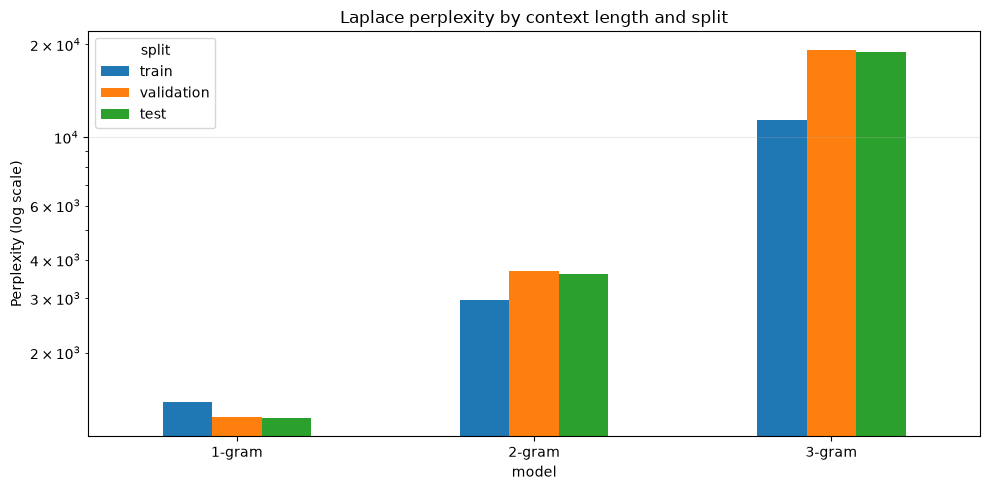

In [12]:
laplace_ppl.plot(kind='bar', figsize=(10, 5), logy=True)
plt.ylabel('Perplexity (log scale)')
plt.title('Laplace perplexity by context length and split')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


### 19.2. Diễn giải

- **Training perplexity:** Với Laplace, perplexity tăng khi chuyển từ unigram sang bigram và trigram. Context càng dài thì dữ liệu càng sparse, trong khi Laplace vẫn phân phối xác suất cho toàn bộ vocabulary nên xác suất của các n-gram đã thấy cũng bị giảm.
- **Validation/test:** Bigram và trigram gặp nhiều n-gram chưa xuất hiện trong training data. Laplace giúp các trường hợp này có xác suất khác 0 nhưng xác suất vẫn rất nhỏ, nên perplexity vẫn cao.
- **Overfitting:** Bigram và đặc biệt là trigram có khoảng cách giữa train và validation/test lớn hơn, cho thấy model khó tổng quát hóa sang dữ liệu mới.
- **Corpus size:** Nếu corpus lớn hơn thì model có thể quan sát được nhiều n-gram hơn, từ đó giảm sparsity và số unseen n-gram.

## 20. Application — Next-word prediction

### 20.1. Năm context thử nghiệm

Dự đoán Top-5 bằng trigram Laplace và đối chiếu với từ thực tế.

Kết quả: chỉ context `machine learning` dự đoán đúng từ `and`; bốn context còn lại có prediction khác actual word.

Riêng context `natural language`, các prediction như `0`, `00`, `000` xuất hiện do cơ chế fallback của hàm prediction kết hợp với Laplace smoothing, không có nghĩa đây là các continuation tốt về ngữ nghĩa.

In [13]:
requested_contexts = [
    ('the', 'cat'),
    ('natural', 'language'),
    ('machine', 'learning'),
    ('climate', 'change'),
    ('software', 'development'),
]

def first_actual_next(context, corpus):
    size = len(context)
    for sentence in corpus:
        for index in range(len(sentence) - size):
            if tuple(sentence[index:index + size]) == tuple(context):
                return sentence[index + size]
    return None

prediction_distributions = trigram_model.next_word_distributions(
    requested_contexts, top_k=5, smoothing='laplace'
)
prediction_rows = []
top5_rows = []
for context in requested_contexts:
    actual = first_actual_next(context, test_sentences)
    actual_source = 'test'
    if actual is None:
        actual = first_actual_next(context, sentences)
        actual_source = 'full 10K corpus'
    distribution = prediction_distributions[tuple(context)]
    predicted, predicted_probability = distribution[0]
    prediction_rows.append({
        'result_type': 'next_word_prediction',
        'model': '3-gram',
        'smoothing': 'laplace',
        'context': ' '.join(context),
        'prediction': predicted,
        'actual': actual,
        'actual_source': actual_source,
        'probability': predicted_probability,
        'correct': predicted == actual,
    })
    for rank, (word, value) in enumerate(distribution, start=1):
        top5_rows.append({
            'result_type': 'next_word_top5',
            'model': '3-gram',
            'smoothing': 'laplace',
            'context': ' '.join(context),
            'rank': rank,
            'prediction': word,
            'probability': value,
        })

prediction_results = pd.DataFrame(prediction_rows)
display(prediction_results[['context', 'prediction', 'actual', 'actual_source', 'probability', 'correct']])
top5_results = pd.DataFrame(top5_rows)
top5_results


,context,prediction,actual,actual_source,probability,correct
0,the cat,house,with,full 10K corpus,0.000063,False
1,natural language,0,processing,full 10K corpus,0.000021,False
2,machine learning,and,and,test,0.000125,True
3,climate change,is,2007,test,0.000292,False
4,software development,kit,talent,test,0.000084,False


,result_type,model,smoothing,context,rank,prediction,probability
0,next_word_top5,3-gram,laplace,the cat,1,house,0.000063
1,next_word_top5,3-gram,laplace,the cat,2,with,0.000042
2,next_word_top5,3-gram,laplace,the cat,3,is,0.000042
3,next_word_top5,3-gram,laplace,the cat,4,lovers,0.000042
4,next_word_top5,3-gram,laplace,the cat,5,and,0.000042
5,next_word_top5,3-gram,laplace,natural language,1,0,0.000021
6,next_word_top5,3-gram,laplace,natural language,2,00,0.000021
7,next_word_top5,3-gram,laplace,natural language,3,000,0.000021
8,next_word_top5,3-gram,laplace,natural language,4,0000,0.000021
9,next_word_top5,3-gram,laplace,natural language,5,0001,0.000021


## 21. Application — Sentence ranking

Xếp hạng câu bằng average log probability; giá trị càng cao càng tốt.

Kết quả: `is useful for NLP` đứng hạng nhất với average log probability `-9.515`; hai câu còn lại cùng đạt khoảng `-10.776`.

In [14]:
ranking_context = 'machine learning'
ranking_candidates = [
    'is useful for NLP',
    'banana computer quickly',
    'studies language models',
]
ranking_rows = []
for candidate in ranking_candidates:
    total_log_probability, predictions = trigram_model.continuation_log_probability(
        ranking_context, candidate, smoothing='laplace', include_eos=True
    )
    ranking_rows.append({
        'result_type': 'sentence_ranking',
        'model': '3-gram',
        'smoothing': 'laplace',
        'context': ranking_context,
        'candidate': candidate,
        'log_probability': total_log_probability,
        'average_log_probability': total_log_probability / predictions,
    })

ranking_results = pd.DataFrame(ranking_rows).sort_values(
    'average_log_probability', ascending=False
).reset_index(drop=True)
ranking_results['rank'] = np.arange(1, len(ranking_results) + 1)
ranking_results


,result_type,model,smoothing,context,candidate,log_probability,average_log_probability,rank
0,sentence_ranking,3-gram,laplace,machine learning,is useful for NLP,-47.574821,-9.514964,1
1,sentence_ranking,3-gram,laplace,machine learning,banana computer quickly,-43.102093,-10.775523,2
2,sentence_ranking,3-gram,laplace,machine learning,studies language models,-43.102093,-10.775523,3


## 22. Error analysis

Phân tích hai dự đoán đúng và hai dự đoán sai trong `error_analysis.md`.

In [15]:
candidate_actual = {}
for sentence in test_sentences:
    for index in range(2, len(sentence)):
        context = tuple(sentence[index - 2:index])
        actual = sentence[index]
        if actual not in {UNK, EOS} and context not in candidate_actual:
            candidate_actual[context] = actual
        if len(candidate_actual) >= 5_000:
            break
    if len(candidate_actual) >= 5_000:
        break

candidate_contexts = list(candidate_actual)
candidate_predictions = trigram_model.next_word_distributions(
    candidate_contexts, top_k=1, smoothing='laplace'
)
correct_cases = []
wrong_cases = []
for context in candidate_contexts:
    prediction, value = candidate_predictions[context][0]
    actual = candidate_actual[context]
    model_context = trigram_model._context(context)
    context_count = trigram_model.context_counts[model_context]
    actual_count = trigram_model.ngram_counts[model_context + (trigram_model._map_word(actual),)]
    if context_count == 0:
        cause = 'unseen context / sparsity'
    elif trigram_model._map_word(actual) == UNK:
        cause = 'vocabulary limitation'
    elif actual_count == 0:
        cause = 'unseen n-gram'
    else:
        cause = 'competing continuation / insufficient data'
    row = {
        'context': ' '.join(context),
        'prediction': prediction,
        'expected': actual,
        'probability': value,
        'context_count': context_count,
        'expected_ngram_count': actual_count,
        'cause': cause,
        'correct': prediction == actual,
    }
    (correct_cases if row['correct'] else wrong_cases).append(row)
    if len(correct_cases) >= 2 and len(wrong_cases) >= 2:
        break

assert len(correct_cases) >= 2 and len(wrong_cases) >= 2
error_cases = pd.DataFrame(correct_cases[:2] + wrong_cases[:2])
error_cases


,context,prediction,expected,probability,context_count,expected_ngram_count,cause,correct
0,year by,the,the,0.000146,16,6,competing continuation / insufficient data,True
1,is by,far,far,0.000209,63,9,competing continuation / insufficient data,True
2,america s,top,best,0.000084,28,2,competing continuation / insufficient data,False
3,s best,to,colleges,0.000209,49,0,unseen n-gram,False


## 23. Context length experiment

**Context dài hơn không phải lúc nào cũng tốt hơn.**

- Với MLE, training perplexity giảm từ `1375.11` xuống `124.66` và `10.28`, cho thấy model bậc cao khớp train tốt hơn.
- Với Laplace, training perplexity tăng từ `1376.97` lên `2955.89` và `11394.42` vì smoothing phân bổ xác suất cho vocabulary lớn trong khi n-gram bậc cao rất sparse.
- Validation perplexity lần lượt là `1235.60`, `3671.15`, `19228.81`; test perplexity là `1225.38`, `3588.69`, `18854.26`. Context dài hơn không cải thiện kết quả held-out.
- Số unique n-gram tăng từ `47,828` lên `963,044` và `2,101,787`; số singleton tương ứng là `0`, `680,231` và `1,833,110`.
- Unseen rate trên test tăng từ `0%` lên `23.91%` và `63.03%`.

Trigram ghi nhớ train tốt nhưng bị sparsity và tổng quát hóa kém. Unigram có test perplexity thấp nhất với Laplace nhưng không xét thứ tự từ; bigram bổ sung thông tin context và ít sparse hơn trigram.

In [16]:
unseen_pivot = unseen_results.pivot(
    index='model', columns='split', values='unseen_event_rate'
).rename(columns={
    'validation': 'validation_unseen_rate',
    'test': 'test_unseen_rate',
})
context_length_results = (
    model_statistics
    .merge(laplace_ppl.reset_index(), on='model', how='left')
    .merge(unseen_pivot.reset_index(), on='model', how='left')
)
context_length_results['generalization_gap'] = (
    context_length_results['test'] - context_length_results['train']
)
context_length_results


,model,vocabulary_size,unique_ngrams,singleton_ngrams,train,validation,test,test_unseen_rate,validation_unseen_rate,generalization_gap
0,1-gram,47828,47828,0,1376.974144,1235.599068,1225.379162,0.000000,0.000000,-151.594983
1,2-gram,47828,963044,680231,2955.890699,3671.152985,3588.691397,0.239060,0.241582,632.800698
2,3-gram,47828,2101787,1833110,11394.421356,19228.805699,18854.261529,0.630328,0.638106,7459.840173


## Xuất deliverable `results.csv`

File gồm perplexity, unseen n-gram, next-word prediction, Top-5 và sentence ranking.

In [17]:
results = pd.concat(
    [perplexity_results, unseen_results, prediction_results, top5_results, ranking_results],
    ignore_index=True,
    sort=False,
)
results.to_csv(RESULTS_PATH, index=False, encoding='utf-8')
print(f'Wrote {len(results)} rows to {RESULTS_PATH}')
results


Wrote 57 rows to D:\Project\NLP-2025\NLP-Labs\labs\lab02\results.csv


,result_type,model,smoothing,split,perplexity,total_ngram_events,unseen_ngram_events,unique_unseen_ngrams,unseen_event_rate,context,prediction,actual,actual_source,probability,correct,rank,candidate,log_probability,average_log_probability
0,perplexity,1-gram,mle,train,1.375107e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,perplexity,1-gram,mle,validation,1.231328e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,perplexity,1-gram,mle,test,1.221261e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,perplexity,1-gram,laplace,train,1.376974e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,perplexity,1-gram,laplace,validation,1.235599e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,perplexity,1-gram,laplace,test,1.225379e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,perplexity,2-gram,mle,train,1.246555e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,perplexity,2-gram,mle,validation,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,perplexity,2-gram,mle,test,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,perplexity,2-gram,laplace,train,2.955891e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 24. Reflection

Nội dung nằm trong `reflection.md`.

## 25. AI assistance statement

Chi tiết được ghi trong `README.md`.

## 26. Individual learning check

Các ý chính:

1. MLE cho xác suất 0 với n-gram chưa xuất hiện.
2. Log probability tránh underflow.
3. Perplexity thấp hơn nghĩa là dự đoán tốt hơn.
4. Trigram có thể kém bigram do sparsity.
5. Smoothing gán xác suất dương cho n-gram chưa thấy.